# Organized Uncertainty Analysis: Ammonia Production Case Study

This notebook provides a clean and organized uncertainty analysis workflow for the ammonia production system, including:

1. **Case Study Setup**: Database initialization and PULPO configuration
2. **Chance-Constrained Pareto Optimization**: Solving the CC-Pareto problem
3. **Monte Carlo Analysis**: Two different uncertainty approaches
4. **Comparative Visualization**: Progressive comparison plots
5. **Choice Analysis**: Technology pathway analysis by risk ranges
6. **CC-Pareto Impact Distributions**: Confidence level analysis

All functions are modularized into separate utility and plotting modules for better organization.

## Configuration and Setup

In [2]:
# Configuration parameters
FORCE_RECALCULATION = False
N_MC_ITERATIONS = 1500
RANDOM_SEED = 666
SOLVER_NAME = "highs"
UNCERTAINTY_CUTOFF = 0.000001
N_TOP_PROCESSES = 19

# File paths
RESULTS_DIR = "data/results"
CC_PARETO_FILE = f"{RESULTS_DIR}/cc_pareto_results.pkl"
MC_STRATEGIES_FILE = f"{RESULTS_DIR}/mc_uncertainty_strategies.pkl"
MC_NORMAL_FILE = f"{RESULTS_DIR}/mc_fitted_normal.pkl"

print("✓ Configuration loaded successfully!")

✓ Configuration loaded successfully!


In [3]:
# Enable automatic reloading of modified modules
%load_ext autoreload
%autoreload 2

# Import required libraries
import os
import numpy as np
import pandas as pd
from pathlib import Path

# Ensure results directory exists
os.makedirs(RESULTS_DIR, exist_ok=True)

# Import our custom modules
import X_uncertainty_utils as utils
import X_uncertainty_plots as plots

# PULPO imports
from pulpo.utils.uncertainty import processor
import pulpo.utils.uncertainty.monte_carlo as mc

print("All libraries imported successfully!")
print("✓ Autoreload enabled - modules will update automatically when modified!")

All libraries imported successfully!
✓ Autoreload enabled - modules will update automatically when modified!


## 1. Database and Project Setup

In [4]:
# Database configuration
PROJECT = "ammonia_final"
DB_NAME = "ecoinvent-3.10-cutoff"
CRED_PATH = Path("/Users/hausslingbhl/Library/CloudStorage/OneDrive-UniversiteitLeiden/01_Administration/02_VITO/04_Systems/credentials.txt")

# Setup databases
utils.setup_ecoinvent_database(PROJECT, DB_NAME, CRED_PATH)
utils.setup_foreground_database("data/ammonia.xlsx", "ammonia", DB_NAME)
utils.setup_impact_methods()

print("\n✓ All databases and methods are ready!")

Database 'ecoinvent-3.10-cutoff' already exists in project 'ammonia_final'.
Database 'ammonia' already exists in project 'ammonia_final'.
Method '('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')' already exists.
Method '('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')' already exists.

✓ All databases and methods are ready!


In [5]:
# Initialize PULPO worker
project, database, method, directory = utils.setup_ammonia_case_study()
pulpo_worker = utils.create_pulpo_worker(project, database, method, directory)
choices, demand, upper_bounds = utils.define_ammonia_problem(pulpo_worker)

# Instantiate the problem
pulpo_worker.instantiate(demand=demand, choices=choices, upper_limit=upper_bounds)

print("\n✓ PULPO worker initialized!")

Creating Instance
Instance created

✓ PULPO worker initialized!
Instance created

✓ PULPO worker initialized!


## 2. Chance-Constrained Pareto Optimization

In [6]:
# Run or load CC-Pareto optimization
if utils.check_file_exists(CC_PARETO_FILE, FORCE_RECALCULATION):
    print(f"Loading existing CC-Pareto results from {CC_PARETO_FILE}...")
    cc_pareto_results = utils.load_results(CC_PARETO_FILE)
else:
    print("Running CC-Pareto optimization...")
    
    # Get uncertainty strategies
    unc_strategies = utils.get_uncertainty_strategies()
    
    # Import and filter uncertainty data
    pulpo_worker.import_and_filter_uncertainty_data(
        cutoff=UNCERTAINTY_CUTOFF,
        scaling_vector_strategy='constructed_demand',
        plot_results=True,
        plot_n_top_processes=N_TOP_PROCESSES
    )
    
    # Apply uncertainty strategies and create CC formulation
    pulpo_worker.apply_uncertainty_strategies(strategies=unc_strategies, drop_undefined=True)
    normal_metadata_env_cost, normal_metadata_var_bounds = pulpo_worker.create_CC_formulation(
        CC_env_cost=True, CC_var_bounds=['upper_limit']
    )
    
    # Solve CC-Pareto problem
    lambda_epsilon_array = np.arange(0.02, 1, 0.02)
    results_CC = pulpo_worker.solve_CC_problem(
        lambda_epsilon_array, normal_metadata_env_cost, normal_metadata_var_bounds, 
        solver_name=SOLVER_NAME
    )
    
    # Package and save results
    cc_pareto_results = {
        'results_CC': results_CC,
        'lambda_epsilon_array': lambda_epsilon_array,
        'normal_metadata_env_cost': normal_metadata_env_cost,
        'normal_metadata_var_bounds': normal_metadata_var_bounds,
        'uncertainty_data': pulpo_worker.uncertainty_data
    }
    utils.save_results(cc_pareto_results, CC_PARETO_FILE)

print(f"\n✓ CC-Pareto optimization completed! Generated {len(cc_pareto_results['results_CC'])} Pareto points")

Loading existing CC-Pareto results from data/results/cc_pareto_results.pkl...
✓ Results loaded from: data/results/cc_pareto_results.pkl

✓ CC-Pareto optimization completed! Generated 49 Pareto points
✓ Results loaded from: data/results/cc_pareto_results.pkl

✓ CC-Pareto optimization completed! Generated 49 Pareto points


## 3. Monte Carlo Analysis (2 approaches)

Loading existing MC results (strategies) from data/results/mc_uncertainty_strategies.pkl...
✓ Results loaded from: data/results/mc_uncertainty_strategies.pkl

✓ MC analysis with custom strategies completed!
✓ Results loaded from: data/results/mc_uncertainty_strategies.pkl

✓ MC analysis with custom strategies completed!


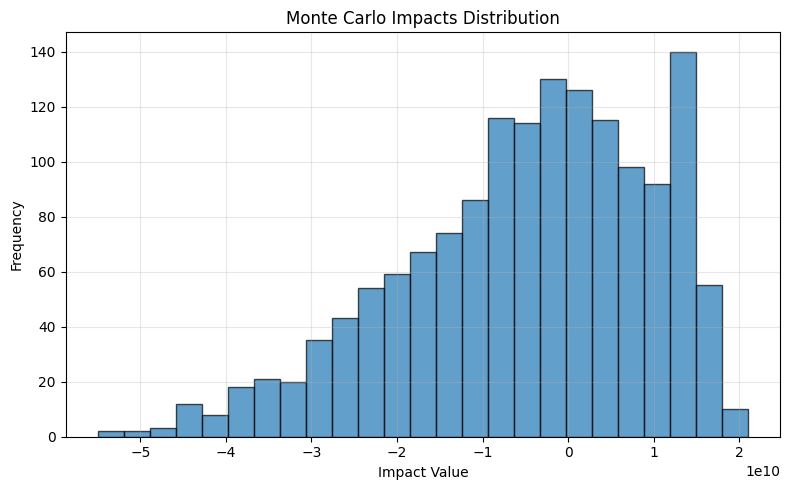


MONTE CARLO ANALYSIS RESULTS

Impact Statistics:
------------------------------------------------------------
count    1.500000e+03
mean    -4.939678e+09
std      1.453490e+10
min     -5.492891e+10
25%     -1.425402e+10
50%     -2.933601e+09
75%      6.393685e+09
max      2.095120e+10
Name: Impact Value, dtype: float64

Top Choices (by frequency):
------------------------------------------------------------
                                                                times_chosen  \
technology  process                                                            
ammonia     nitrogen + hydrogen | ammonia | RER                         1476   
methane     market for biomethane | biomethane, 24 bar | RER            1357   
biogas      anaerobic digestion of agricultural residues | ...          1179   
biomethane  upgrading chemical scrubbing (CCS) | biomethane...          1103   
hydrogen    steam methane reforming (CCS) | hydrogen | RER              1049   
biogas      anaerobic digest

In [7]:
# Monte Carlo Analysis 1: Custom Uncertainty Strategies
if utils.check_file_exists(MC_STRATEGIES_FILE, FORCE_RECALCULATION):
    print(f"Loading existing MC results (strategies) from {MC_STRATEGIES_FILE}...")
    mc_strategies_results = utils.load_results(MC_STRATEGIES_FILE)
else:
    print(f"Running Monte Carlo analysis with custom strategies ({N_MC_ITERATIONS} iterations)...")
    
    pulpo_worker.instantiate(demand=demand, choices=choices, upper_limit=upper_bounds)
    unc_strategies = utils.get_uncertainty_strategies()
    
    pulpo_worker.import_and_filter_uncertainty_data(
        cutoff=UNCERTAINTY_CUTOFF, scaling_vector_strategy='constructed_demand',
        plot_results=False, plot_n_top_processes=N_TOP_PROCESSES
    )
    pulpo_worker.apply_uncertainty_strategies(strategies=unc_strategies, drop_undefined=True)
    
    mc_strategies_results = pulpo_worker.run_mc_from_uncertainty(
        n_samples=N_MC_ITERATIONS, seed=RANDOM_SEED, solver_name=SOLVER_NAME, options=None
    )
    utils.save_results(mc_strategies_results, MC_STRATEGIES_FILE)

print("\n✓ MC analysis with custom strategies completed!")
analysis_strategies = utils.analyze_MC_results(mc_strategies_results, show_plot=True)

Loading existing MC results (normal) from data/results/mc_fitted_normal.pkl...

✓ Results loaded from: data/results/mc_fitted_normal.pkl

✓ MC analysis with normal distributions completed!
✓ Results loaded from: data/results/mc_fitted_normal.pkl

✓ MC analysis with normal distributions completed!


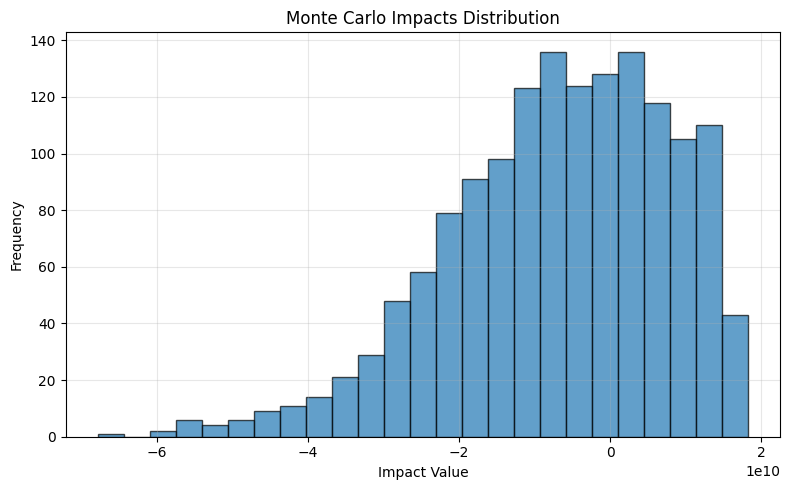


MONTE CARLO ANALYSIS RESULTS

Impact Statistics:
------------------------------------------------------------
count    1.500000e+03
mean    -6.918320e+09
std      1.475373e+10
min     -6.778833e+10
25%     -1.626204e+10
50%     -5.510948e+09
75%      4.462431e+09
max      1.821291e+10
Name: Impact Value, dtype: float64

Top Choices (by frequency):
------------------------------------------------------------
                                                                times_chosen  \
technology  process                                                            
ammonia     nitrogen + hydrogen | ammonia | RER                         1441   
methane     market for biomethane | biomethane, 24 bar | RER            1401   
biogas      anaerobic digestion of agricultural residues | ...          1258   
            anaerobic digestion of sequential crop | biogas...          1157   
hydrogen    steam methane reforming (CCS) | hydrogen | RER              1151   
biomethane  upgrading chemic

In [8]:
# Monte Carlo Analysis 2: Fitted Normal Distributions
if utils.check_file_exists(MC_NORMAL_FILE, FORCE_RECALCULATION):
    print(f"Loading existing MC results (normal) from {MC_NORMAL_FILE}...")
    mc_normal_results = utils.load_results(MC_NORMAL_FILE)
else:
    print(f"Running Monte Carlo analysis with fitted normal distributions ({N_MC_ITERATIONS} iterations)...")
    
    pulpo_worker.instantiate(demand=demand, choices=choices, upper_limit=upper_bounds)
    unc_strategies = utils.get_uncertainty_strategies()
    
    pulpo_worker.import_and_filter_uncertainty_data(
        cutoff=UNCERTAINTY_CUTOFF, scaling_vector_strategy='constructed_demand',
        plot_results=False, plot_n_top_processes=N_TOP_PROCESSES
    )
    pulpo_worker.apply_uncertainty_strategies(strategies=unc_strategies, drop_undefined=True)
    
    # Transform distributions to normal
    pulpo_worker.uncertainty_data = processor.transform_to_normal(
        pulpo_worker.uncertainty_data, sample_size=100, plot_distribution=False
    )
    
    mc_normal_results = pulpo_worker.run_mc_from_uncertainty(
        n_samples=N_MC_ITERATIONS, seed=RANDOM_SEED, solver_name=SOLVER_NAME, options=None
    )
    utils.save_results(mc_normal_results, MC_NORMAL_FILE)

print("\n✓ MC analysis with normal distributions completed!")
analysis_normal = utils.analyze_MC_results(mc_normal_results, show_plot=True)

## 4. Comparative Analysis and Visualization

In [9]:
# Create comparative summary table
comparison_df = plots.create_summary_table(analysis_strategies, analysis_normal)


COMPARATIVE ANALYSIS - ALL MONTE CARLO APPROACHES

          Approach   Mean Impact      Std Dev    Min Impact   Max Impact      CV (%)
Custom Strategies -4.939678e+09 1.453490e+10 -5.492891e+10 2.095120e+10 -294.247910
    Fitted Normal -6.918320e+09 1.475373e+10 -6.778833e+10 1.821291e+10 -213.255884



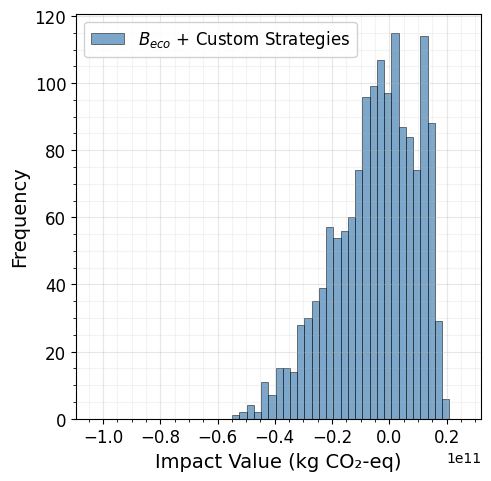

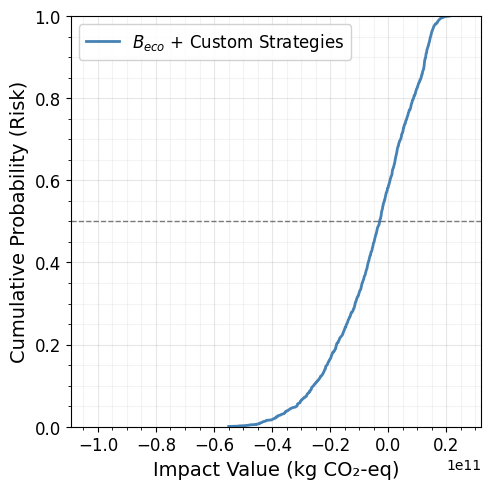

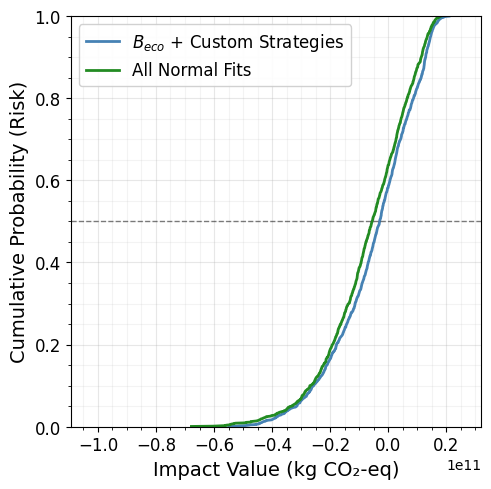

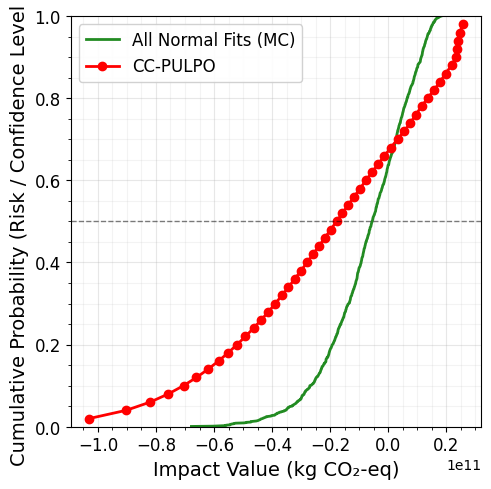


✓ Four progressive comparison plots saved:
  1. data/results/mc_comparison_1_histogram.png - Custom strategies histogram
  2. data/results/mc_comparison_2_cumulative_strategies.png - Custom strategies cumulative risk
  3. data/results/mc_comparison_3_cumulative_all.png - + Normal fits
  4. data/results/mc_comparison_4_cc_vs_mc.png - CC-Pareto vs MC comparison


In [10]:
# Generate progressive comparative plots
plots.plot_comparative_mc_analysis(
    analysis_strategies, analysis_normal, 
    cc_pareto_results, RESULTS_DIR
)

## 5. Choice Analysis within Risk Ranges

In [11]:
# Analyze technology choices across different risk ranges
print("=" * 80)
print("CHOICE ANALYSIS FOR DIFFERENT RISK SCENARIOS")
print("=" * 80)

risk_ranges = [(0.5, 0.6), (0.6, 0.7), (0.7, 0.8), (0.8, 0.9), (0.9, 0.95), (0.95, 1.0)]

risk_analysis_results = {
    f"{int(a*100)}%-{int(b*100)}%": res
    for (a, b) in risk_ranges
    if (res := utils.analyze_choices_in_risk_range(
        mc_normal_results, analysis_normal, a, b, f"{int(a*100)}%-{int(b*100)}%"
    ))
}

print("\n" + "=" * 80)
print("CHOICE ANALYSIS COMPLETE")
print("=" * 80)

CHOICE ANALYSIS FOR DIFFERENT RISK SCENARIOS

50%-60% — Risk 50%–60% | Impact range: [-5.49e+09, -1.28e+09] kg CO₂-eq
Found 151 iterations in range.

BIOGAS Technology Choices:
                                                             Value      Capacity
Metadata                                                                      
anaerobic digestion of agricultural residues | ...  1.600000e+10  1.600000e+10
anaerobic digestion of sequential crop | biogas...  1.400000e+10  1.400000e+10: 70/151 (46.4%)
                                                             Value      Capacity
Metadata                                                                      
anaerobic digestion of agricultural residues | ...  1.600000e+10  1.600000e+10
anaerobic digestion of sequential crop | biogas... -0.000000e+00  1.400000e+10: 25/151 (16.6%)
                                                             Value      Capacity
Metadata                                                                  

Choice analysis plot saved to: data/results/choice_analysis_by_risk.png


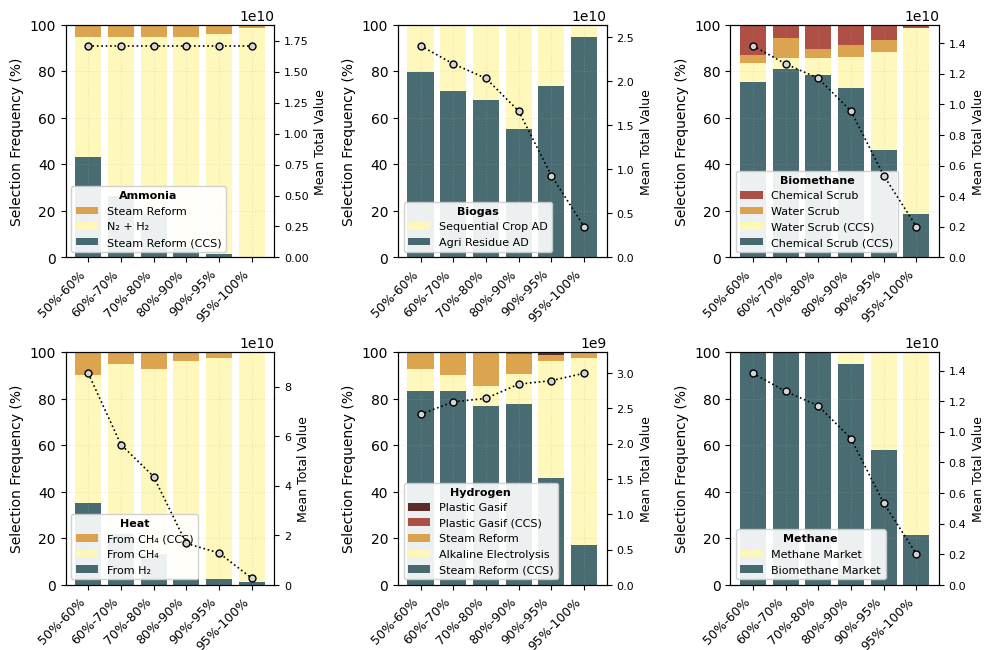

In [12]:
# Visualize choice analysis
plots.plot_choice_analysis(
    risk_analysis_results, mc_normal_results, 
    f"{RESULTS_DIR}/choice_analysis_by_risk.png"
)

## 6. CC-Pareto Impact Distribution Analysis

In [13]:
# Generate overlay samples and calculate CC-Pareto impact distributions
N_SAMPLES = 1000
CC_CONFIDENCE_LEVELS = [0.5, 0.74, 0.86, 0.98]

print(f"Generating {N_SAMPLES} overlay samples...")

# Setup uncertainty for overlay sampling
unc_strategies = utils.get_uncertainty_strategies()
pulpo_worker.import_and_filter_uncertainty_data(
    cutoff=UNCERTAINTY_CUTOFF, scaling_vector_strategy='constructed_demand',
    plot_results=False, plot_n_top_processes=N_TOP_PROCESSES
)
pulpo_worker.apply_uncertainty_strategies(strategies=unc_strategies, drop_undefined=True)
pulpo_worker.create_CC_formulation(CC_env_cost=True, CC_var_bounds=['upper_limit'])

# Generate overlay samples
overlay_samples = mc.pre_sample_from_uncertainty(pulpo_worker, n_samples=N_SAMPLES, seed=RANDOM_SEED)

# Calculate impact distributions for each confidence level
print("\nCalculating impact distributions for CC-Pareto confidence levels:")
impact_distributions = {}

for lambda_val in CC_CONFIDENCE_LEVELS:
    if lambda_val in cc_pareto_results['results_CC']:
        s_vector = cc_pareto_results['results_CC'][lambda_val]['Scaling Vector'].sort_index()
        level_name = f"λ = {lambda_val}"
        impact_distributions[lambda_val] = utils.calculate_impact_distribution(
            overlay_samples, s_vector, level_name
        )
    else:
        print(f"Warning: λ = {lambda_val} not found in CC-Pareto results")

print(f"\n✓ Impact distributions calculated for {len(impact_distributions)} confidence levels")

Generating 1000 overlay samples...
chosen environmental impact method: ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')
The total impact is: 4.926667e+01
Characterized inventory: (2648, 23569) 21178
Filtered characterized inventory: (2648, 23569) 2696
Deviation from LCA score: 0.000864956044623888
inventory (2648, 23569) filtering resulted in 2696 of 21178 exchanges (99.91% of total impact) and took 0.002 seconds.
CHARACTERIZATION MATRIX (2648,) filtering resulted in 40 of 91 characterization factors
Intervention flows:
In ecoinvent-3.10-cutoff:
chosen environmental impact method: ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')
The total impact is: 4.926667e+01
Characterized inventory: (2648, 23569) 21178
Filtered characterized inventory: (2648, 23569) 2696
Deviation from LCA score: 0.000864956044623888
inventory (2648, 23569) filtering resulted in 2696 of 21178 exchanges (99.91% of total impact) and took 0.002 seconds.

Sampling uncertainty draws: 100%|██████████| 1000/1000 [01:22<00:00, 12.06it/s]




Calculating impact distributions for CC-Pareto confidence levels:
✓ λ = 0.5: Mean = 8.55e+08, Std = 2.07e+10
✓ λ = 0.5: Mean = 8.55e+08, Std = 2.07e+10
✓ λ = 0.74: Mean = 1.58e+09, Std = 1.56e+10
✓ λ = 0.74: Mean = 1.58e+09, Std = 1.56e+10
✓ λ = 0.86: Mean = 4.00e+09, Std = 1.29e+10
✓ λ = 0.86: Mean = 4.00e+09, Std = 1.29e+10
✓ λ = 0.98: Mean = 1.47e+10, Std = 2.26e+09

✓ Impact distributions calculated for 4 confidence levels
✓ λ = 0.98: Mean = 1.47e+10, Std = 2.26e+09

✓ Impact distributions calculated for 4 confidence levels


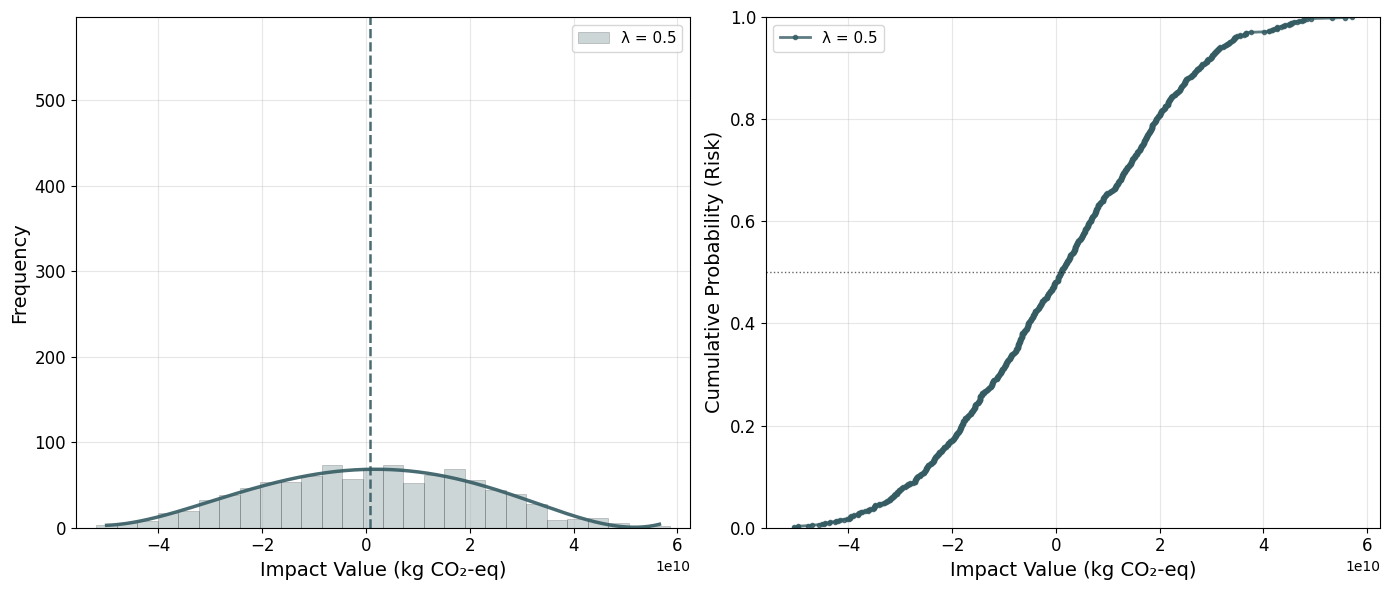

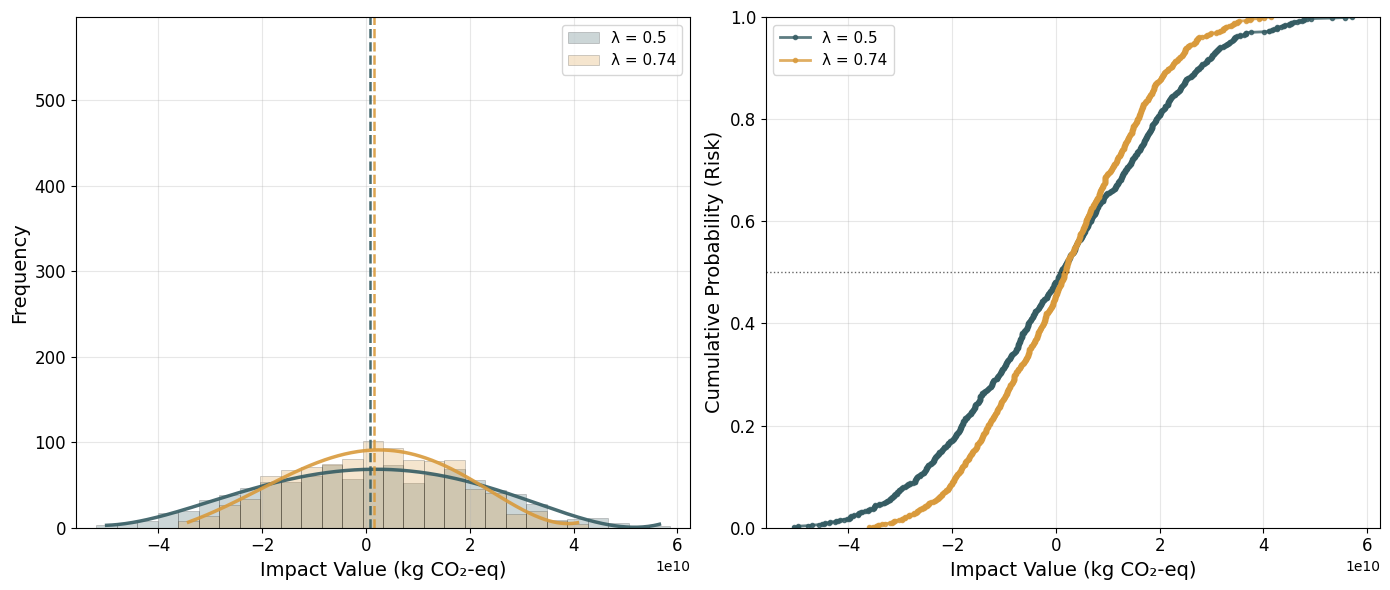

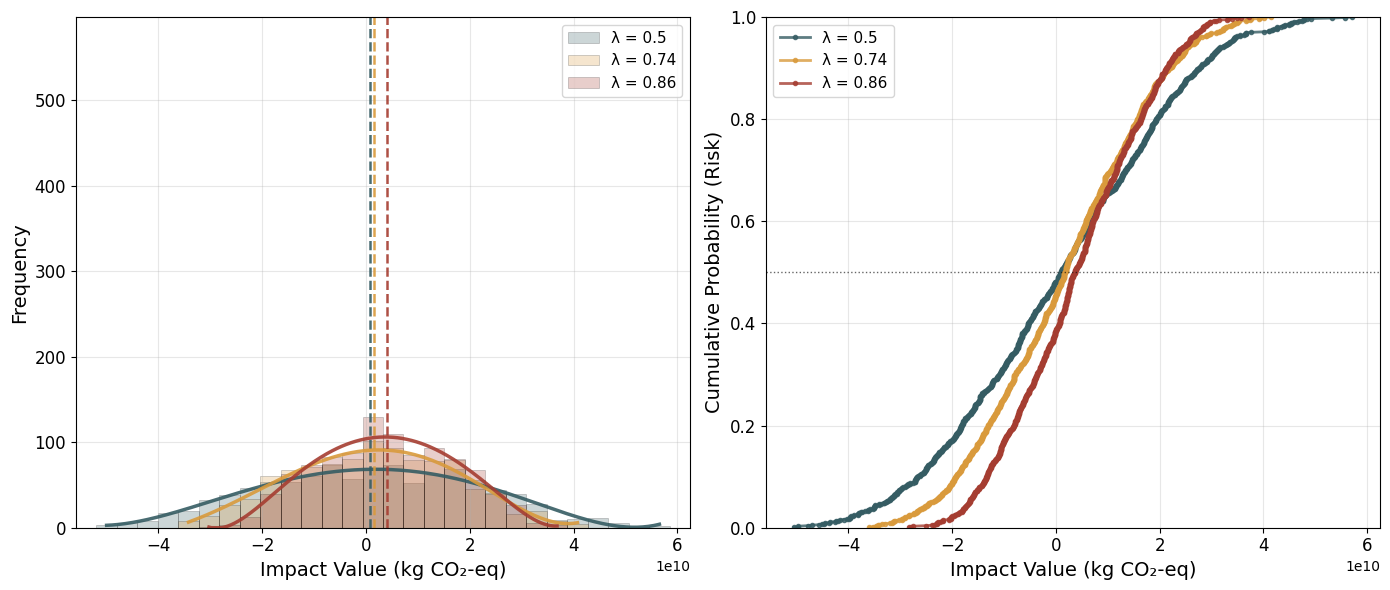

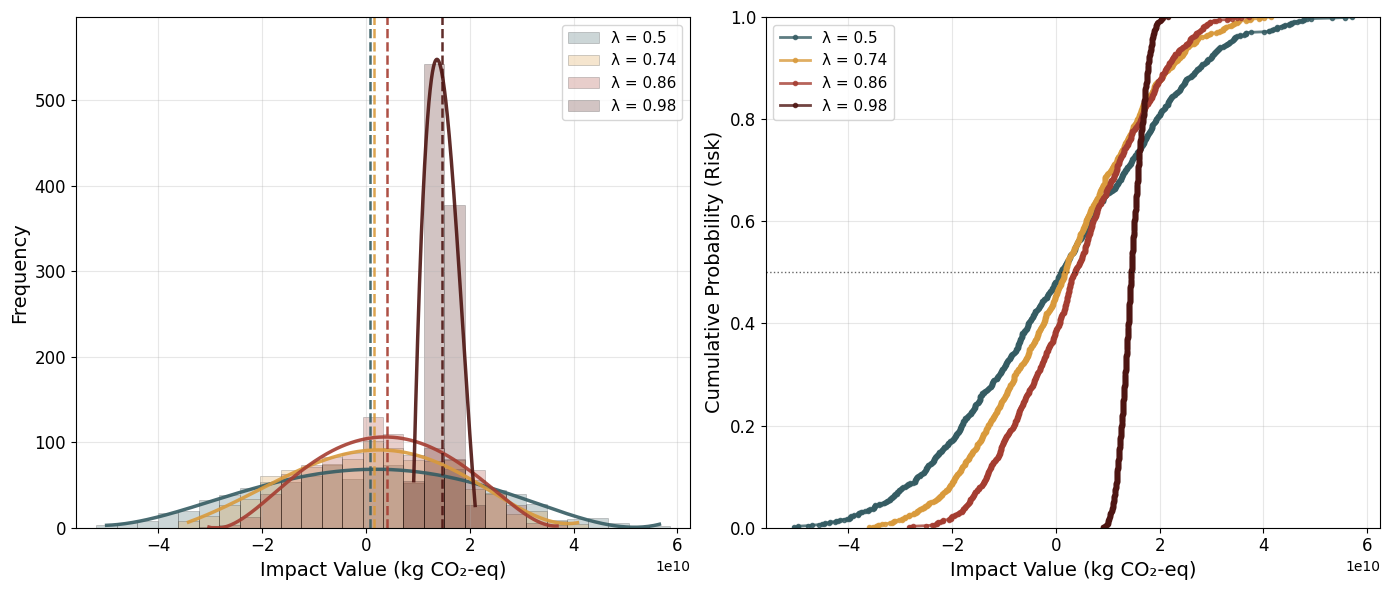


✓ Saved 4 incremental CC-Pareto distribution figures to data/results

CC-PARETO IMPACT DISTRIBUTION SUMMARY
 Confidence Level (λ) Mean Impact  Std Dev CV (%) Min Impact Max Impact 5th Percentile 95th Percentile
                 0.50    8.55e+08 2.07e+10 2417.3  -5.05e+10   5.71e+10      -3.26e+10        3.35e+10
                 0.74    1.58e+09 1.56e+10  989.5  -3.60e+10   4.14e+10      -2.38e+10        2.69e+10
                 0.86    4.00e+09 1.29e+10  322.9  -2.83e+10   3.72e+10      -1.66e+10        2.55e+10
                 0.98    1.47e+10 2.26e+09   15.4   9.04e+09   2.15e+10       1.11e+10        1.85e+10

✓ CC-Pareto impact distribution analysis completed!
✓ Visualization saved to: data/results/cc_pareto_impact_distributions.png


In [17]:
# Visualize CC-Pareto impact distributions
plots.plot_cc_pareto_distributions(impact_distributions, RESULTS_DIR)

# Create summary statistics table
print("\n" + "="*80)
print("CC-PARETO IMPACT DISTRIBUTION SUMMARY")
print("="*80)

summary_data = []
for lambda_val, impacts in impact_distributions.items():
    summary_data.append({
        'Confidence Level (λ)': lambda_val,
        'Mean Impact': f"{np.mean(impacts):.2e}",
        'Std Dev': f"{np.std(impacts):.2e}",
        'CV (%)': f"{np.std(impacts)/np.mean(impacts)*100:.1f}",
        'Min Impact': f"{np.min(impacts):.2e}",
        'Max Impact': f"{np.max(impacts):.2e}",
        '5th Percentile': f"{np.percentile(impacts, 5):.2e}",
        '95th Percentile': f"{np.percentile(impacts, 95):.2e}"
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print("="*80)

print(f"\n✓ CC-Pareto impact distribution analysis completed!")
print(f"✓ Visualization saved to: {RESULTS_DIR}/cc_pareto_impact_distributions.png")

## 7. Analysis Summary

In [54]:
import X_plot as x_plots

Generating Pareto front plot from CC results...


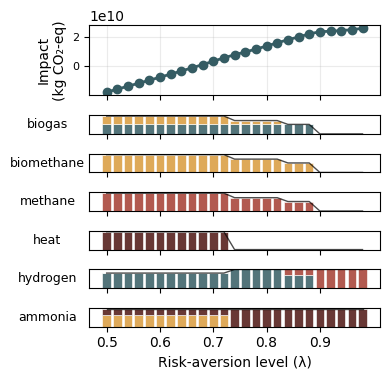

Pareto plot saved to: {'combined': 'data/results\\pareto_and_choices_combined.png'}


In [72]:
# Plot Pareto / CC results from results_CC
print('Generating Pareto front plot from CC results...')
plot_path = x_plots.plot_pareto_from_results(cc_pareto_results['results_CC'], process_map_metadata=None, cutoff_value=0.01, results_dir=RESULTS_DIR, lambda_range=(0.5,0.98))
print(f'Pareto plot saved to: {plot_path}')

In [59]:
# Final summary
print("\n" + "="*80)
print("UNCERTAINTY ANALYSIS COMPLETE")
print("="*80)
print(f"\nTotal iterations per MC approach: {N_MC_ITERATIONS}")
print(f"Random seed: {RANDOM_SEED}")
print(f"Solver: {SOLVER_NAME}")
print(f"\nAll results saved to: {RESULTS_DIR}")
print("Files generated:")
print(f"  1. {CC_PARETO_FILE}")
print(f"  2. {MC_STRATEGIES_FILE}")
print(f"  3. {MC_NORMAL_FILE}")
print(f"  4. {RESULTS_DIR}/mc_comparison_*.png (4 cumulative risk plots)")
print(f"  5. {RESULTS_DIR}/choice_analysis_by_risk.png")
print(f"  6. {RESULTS_DIR}/cc_pareto_impact_distributions.png")
print("Analysis Components:")
print("  ✓ Chance-Constrained Pareto Optimization")
print("  ✓ Monte Carlo Analysis (2 approaches)")
print("  ✓ Cumulative Risk Comparison")
print("  ✓ Technology Choice Analysis by Risk Range")
print("  ✓ CC-Pareto Impact Distribution Analysis")
print("\n" + "="*80)
print("\n✓ Organized uncertainty analysis workflow completed successfully!")


UNCERTAINTY ANALYSIS COMPLETE

Total iterations per MC approach: 1500
Random seed: 666
Solver: highs

All results saved to: data/results
Files generated:
  1. data/results/cc_pareto_results.pkl
  2. data/results/mc_uncertainty_strategies.pkl
  3. data/results/mc_fitted_normal.pkl
  4. data/results/mc_comparison_*.png (4 cumulative risk plots)
  5. data/results/choice_analysis_by_risk.png
  6. data/results/cc_pareto_impact_distributions.png
Analysis Components:
  ✓ Chance-Constrained Pareto Optimization
  ✓ Monte Carlo Analysis (2 approaches)
  ✓ Cumulative Risk Comparison
  ✓ Technology Choice Analysis by Risk Range
  ✓ CC-Pareto Impact Distribution Analysis


✓ Organized uncertainty analysis workflow completed successfully!
